In [21]:
#Allfold_universe_file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Clu_all_10.txt'
Allfold_universe_file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Mem_all.txt'
#Map_file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/univer_10.txt'
Map_file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Clu_all.txt'

In [22]:
Allfold_universe = open(Allfold_universe_file,'r')
Allfold_universe_data = {}
values_all = []
values = []
for line in Allfold_universe:
    key = line.split('\t')[0]
    values_all.append(line.split('\t')[1])
    if int(line.split('\t')[2]) == 1 or int(line.split('\t')[2])==2:
        values.append(line.split('\t')[1])
        if key in Allfold_universe_data.keys():
            Allfold_universe_data[key].append(line.split('\t')[1])
        else:
            Allfold_universe_data[key] = []
            Allfold_universe_data[key].append(line.split('\t')[1])

In [7]:
len(Allfold_universe_data.values())

2982

In [23]:
local2Universe = open(Map_file,'r') 
local2Universe_data = {}
for line in local2Universe:
    key = line.split('\t')[1]
    if key in local2Universe_data.keys():
        local2Universe_data[key].append(line.split('\t')[0])
    else:
        local2Universe_data[key] = line.split('\t')[0]

In [10]:
Universe2Local = open(Map_file,'r') 
Universe2Local_data = {}
keys = []
for line in Universe2Local:
    key = line.split('\t')[0]
    #if key in Universe2Local_data.keys():
       # keys.append(key)
       # Universe2Local_data[key].append(line.split('\t')[1])
    #else:
    Universe2Local_data[key] = line.split('\t')[1]

In [10]:
Universe2Local_data_keyM = {}
items = []
for key in keys:
    Universe2Local_data_keyM[key] = Universe2Local_data[key]
    items.extend(Universe2Local_data[key])

In [97]:
Allfold_universe_len = []
Allfold_universe_len_true = []
Allfold_universe_len_false = []
for key in Allfold_universe_data.keys():
    Allfold_universe_len.append(len(Allfold_universe_data[key]))
    if Universe2Local_data[key] in uni_fun_fold_keys:
        Allfold_universe_len_true.append(len(Allfold_universe_data[key]))
    else:
        Allfold_universe_len_false.append(len(Allfold_universe_data[key]))

In [ ]:
Allfold_universe_len_key = []
Allfold_universe_len_true_key = []
Allfold_universe_len_false_key = []
for key in Allfold_universe_data.keys():
    if len(Allfold_universe_data[key]) > 1000 and len(Allfold_universe_data[key]) < 2000:
        Allfold_universe_len_key.append(key)
        if Universe2Local_data[key] in uni_fun_fold_keys:
            Allfold_universe_len_true_key.append(key)
        else:
            Allfold_universe_len_false_key.append(key)

In [331]:
len(Allfold_universe_data[local2Universe_data['P20921']])

34425

In [334]:
len(fun_fold['Q7N2V3'])

51

In [ ]:
Univer_case = []
local_case = []
for key in Allfold_universe_len_key:
    Univer_case.extend(Allfold_universe_data[key])
    local_case.extend(fun_fold[Universe2Local_data[key]])

In [146]:
len(Univer_case)

629077

In [151]:
import requests

url = 'https://cluster.foldseek.com/api/cluster/A0A010R299/members?format=fasta&groupBy=&groupDesc=&itemsPerPage=10&multiSort=false&mustSort=false&page=1&sortBy=&sortDesc=false'
response = requests.get(url)

with open('/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Universe_1000_2000/sample.fasta', 'wb') as f:
    f.write(response.content)


In [166]:
import requests 
def get_fasta_universe(key):
    url = 'https://cluster.foldseek.com/api/cluster/'+key+'/members?format=fasta&flagFilter=1&groupBy=&groupDesc=&itemsPerPage=10&multiSort=false&mustSort=false&page=1&sortBy=&sortDesc=false'
    response = requests.get(url)
    file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Universe_con_augu_fasta/' + key + '.fasta'
    
    with open(file, 'wb') as f:
        f.write(response.content)


In [164]:
key = 'A0A010R299'
get_fasta_universe(key)

In [191]:
len(Allfold_universe_len_key)

438

In [190]:
for key in Allfold_universe_data.keys():
    keys = key + '.fasta'
    if keys not in Uni_list:
        get_fasta_universe(key)

In [51]:
len(Uni_list)

2982

In [53]:
dirs = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Universe_fasta/'
def merge_fasta_files(input_files, output_file):
    with open(output_file, 'w') as out_f:
        for input_file in input_files:
            with open(dirs+input_file, 'r') as in_f:
                for line in in_f:
                    out_f.write(line)

# 要合并的FASTA文件列表
input_files = Uni_list
# 合并后的输出文件
output_file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Universe_all.fasta'

# 合并FASTA文件
merge_fasta_files(input_files, output_file)

In [10]:
#!pip install biopython
from Bio import SeqIO

def fasta_to_dict(fasta_file):
    sequences = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequences[record.id] = str(record.seq)
    return sequences

file_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Universe_all.fasta'
sequences_dict = fasta_to_dict(file_path)

In [18]:


# Remove the version number from UniProt identifiers
cleaned_Uni_list = [item.split('.')[0] for item in Uni_list]

# Define the output FASTA file path
output_fasta_file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Universe_rep.fasta'

# Write the sequences to the FASTA file
with open(output_fasta_file, 'w') as fasta_file:
    for uni_id in cleaned_Uni_list:
        if uni_id in sequences_dict:
            fasta_file.write(f">{uni_id}\n")
            fasta_file.write(f"{sequences_dict[uni_id]}\n")
        else:
            print(f"Warning: Sequence for UniProt ID {uni_id} not found in the dictionary.")
            
print(f"FASTA file '{output_fasta_file}' created successfully.")


FASTA file '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Universe_rep.fasta' created successfully.


In [175]:
import csv

def fasta_to_csv(csv_file):
    with open(csv_file, 'w', newline='') as tsvfile:
        
        #writer.writerow(['ID', 'EC Annotation', 'Sequence'])
        for key in sequences_dict.keys():
            id = key
            description = EC_anno[key]
            sequence = sequences_dict[key]
            tsvfile.write(f"{id}\t{description}\t{sequence}\n")

csv_file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/pos_con_augu.csv'

# Convert FASTA to CSV
fasta_to_csv(csv_file)

In [25]:
Allfold_universe_lenR = []
Allfold_universe_lenR_true = []
Allfold_universe_lenR_false = []
for key in Allfold_universe_data.keys():
    Allfold_universe_lenR.append(len(Allfold_universe_data[key])/len(fun_fold[Universe2Local_data[key]]))
    if Universe2Local_data[key] in uni_fun_fold_keys:
        Allfold_universe_lenR_true.append(len(Allfold_universe_data[key])/len(fun_fold[Universe2Local_data[key]]))
    else:
        Allfold_universe_lenR_false.append(len(Allfold_universe_data[key])/len(fun_fold[Universe2Local_data[key]]))

In [52]:
np.mean(Allfold_universe_lenR)

1276.6377182837196

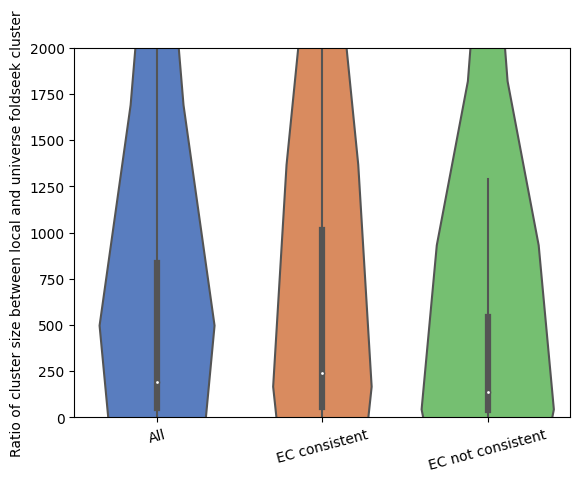

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = Allfold_universe_lenR
data2 = Allfold_universe_lenR_true
data3 = Allfold_universe_lenR_false
# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2,data3], palette="muted", orient='v')

#plt.title('Vertical Violin Plot - Data Distribution')
#plt.xlabel('Density')
plt.ylabel('Ratio of cluster size between local and universe foldseek cluster')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['All', 'EC consistent','EC not consistent'])
plt.xticks(rotation=15)
plt.ylim(-0.0005, 2000) 
plt.show()

In [39]:
fun_fold_len = []
fun_fold_len_true = []
fun_fold_len_false = []
for key in fun_fold.keys():
    fun_fold_len.append(len(fun_fold[key]))
    if key in uni_fun_fold_keys:
        fun_fold_len_true.append(len(fun_fold[key]))
    else:
        fun_fold_len_false.append(len(fun_fold[key]))

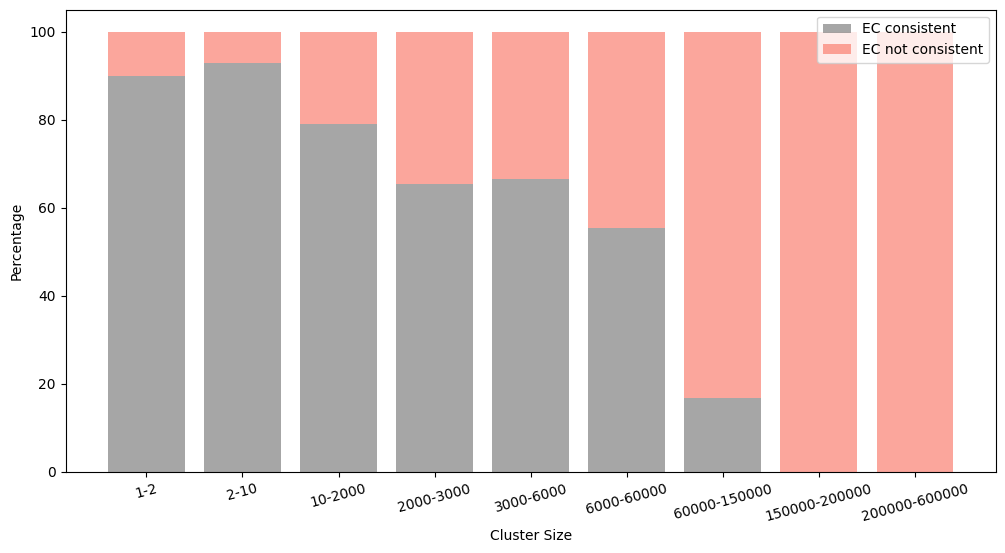

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def cluster_size_count(your_list):
    counter = Counter(your_list)
    segment_counts = {segment: 0 for segment in segments}
    for element, count in counter.items():
        for segment in segments:
            if segment[0] <= element < segment[1]:
                segment_counts[segment] += count
    return segment_counts

# 定义segments和获取两个数据集的计数
segments = [(1, 2), (2, 10), (10, 2000),(2000, 3000), (3000, 6000),(6000, 60000),(60000, 150000), (150000, 200000),(200000, 600000)]
counts_fold = cluster_size_count(Allfold_universe_len_true)
counts_fli = cluster_size_count(Allfold_universe_len_false)


# 计算每个段内的百分比
percentages_fold = {segment: (count / (count+counts_fli[segment])) * 100 for segment, count in counts_fold.items()}
percentages_fli = {segment: (count / (count+counts_fold[segment])) * 100 for segment, count in counts_fli.items()}

# 将百分比转换为NumPy数组以便堆积
fold_percentages = np.array(list(percentages_fold.values()))
fli_percentages = np.array(list(percentages_fli.values()))

# 画百分比堆积图
plt.figure(figsize=(12, 6))
plt.bar(range(len(segments)), fold_percentages, color='gray', alpha=0.7, label='EC consistent', tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])
plt.bar(range(len(segments)), fli_percentages, bottom=fold_percentages, color='salmon', alpha=0.7, label='EC not consistent')

plt.xlabel('Cluster Size')
plt.ylabel('Percentage')
plt.xticks(rotation=15)
plt.legend()
plt.show()


No handles with labels found to put in legend.


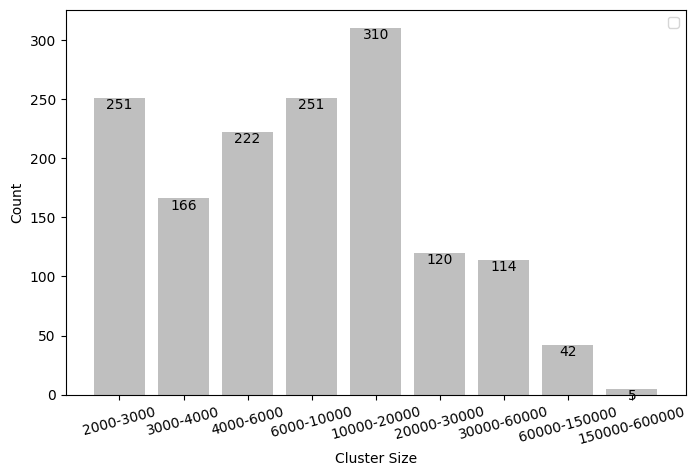

In [195]:
import matplotlib.pyplot as plt
from collections import Counter

#segments = [(1, 2), (2, 10),(10, 100),(100, 500),(500, 1000),(1000, 2000)]
segments = [(2000, 3000), (3000, 4000),(4000, 6000),(6000, 10000),(10000, 20000),(20000, 30000),(30000, 60000),(60000, 150000), (150000, 600000)]


def cluster_size_count(your_list):

    counter = Counter(your_list)
    #segments = [(50, 100),(100, 200),(200, 350),(350, 500),(500, 700),(700, 900)]

    segment_counts = {segment: 0 for segment in segments}

    for element, count in counter.items():
        for segment in segments:
            if segment[0] <= element < segment[1]:
                segment_counts[segment] += count
    return segment_counts
# 将统计结果转换为两个列表，分别包含段和对应的计数
_,  counts_fold = zip(*cluster_size_count(Allfold_universe_len).items())
#_,  counts_fli = zip(*cluster_size_count(Allfold_universe_len_false).items())

# 画柱状图
plt.figure(figsize=(8, 5))
bars_fold = plt.bar(range(len(segments)), counts_fold,color='gray', alpha=0.5, tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])
#bars_fli = plt.bar(range(len(segments)), counts_fli,color='salmon', alpha=0.5,label='EC not consistent' , tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])

plt.xlabel('Cluster Size')
plt.ylabel('Count')
#plt.title('Segmented Counts')
plt.grid(False)
for bar in bars_fold:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='top')
#for bar in bars_fli:
#    yval = bar.get_height()
#    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')
plt.legend()
plt.xticks(rotation=15)
plt.show()

In [1]:
file1 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/uniprotkb_AND_reviewed_true_2023_07_03.tsv'
file3 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/all_cluster.tsv'
file4 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/afall_ID50_cluster.tsv'
file5 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/select_cluster.tsv'
from CLEAN.utils import *
dirs = "/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/"
id_ec, ec_id =  get_ec_id_dict(dirs+'data/split100' + '.csv')

In [2]:
rep_seq = {}
rep_fold = {}
seqfile = open(file3,'r')
for line in seqfile:
    key = line.split('\t')[0]
    if key in rep_seq.keys():
        rep_seq[key].append(line.split('\t')[1].split('\n')[0])
    else:
        rep_seq[key] = []
        rep_seq[key].append(line.split('\t')[1].split('\n')[0])
        
foldfile = open(file5,'r')
for line in foldfile:
    key = line.split('\t')[0].split('.')[0]
    if key in rep_fold.keys():
        rep_fold[key].append(line.split('\t')[1].split('.')[0])
    else:
        rep_fold[key] = []
        rep_fold[key].append(line.split('\t')[1].split('.')[0])

In [3]:
import os
import numpy as np
def get_pLDDT(pdb_p):
    infile = open(pdb_p,'r')
    pLDDT = []
    for line in infile:
          if line[0:6].rstrip() == 'ATOM' and line[13:15].rstrip() == 'CA':
            pLDDT.append(float(line[60:65].rstrip()))
    infile.close()
    return np.mean(pLDDT)
af_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/afall/'
af_list = os.listdir(af_path)
rep_structure = []
rep_pLDDT = []
keys = []
for key in rep_seq.keys():
    pLDDTs = []
    items = []
    for item in rep_seq[key]:
        item_name = item + '.pdb'
        if item_name in af_list:
            pdb_p = af_path+ item + '.pdb'
            pLDDTs.append(get_pLDDT(pdb_p))
            items.append(item)
    if len(pLDDTs)>0:
        max_plddt = max(pLDDTs)
        rep_pLDDT.append(max_plddt)
        rep_structure.append(items[pLDDTs.index(max_plddt)])
        keys.append(key)

In [4]:
threshold_value = 90 
positions = [index for index, value in enumerate(rep_pLDDT) if value > threshold_value]

sel_struc=[rep_structure[index ]for index in positions]
sel_keys = [keys[index ]for index in positions]


In [5]:
fun_fold = {}
sort_items = []
sel_seq = {}
for key in rep_fold.keys():
    fun_fold[key] = []
    
    for item in rep_fold[key]:
        if item in sel_struc:
            k = sel_keys[sel_struc.index(item)]
            fun_fold[key].extend(rep_seq[k])
            sel_seq[k] = rep_seq[k]
        
            sort_items.extend(rep_seq[k])
        #print(key,item,len(sort_items))
        if item not in sel_struc and len(rep_fold[key])==1:
            fun_fold[key].append(key)
            sort_items.append(key)

In [7]:
len(sort_items)

194521

In [6]:
fun_check = {}
fun_key = {}
fold_index = []
fold_items = []
for key in fun_fold.keys():
    fun_key[key] = id_ec[key]
    fun_check[key]= []
    for item in fun_fold[key]:
        fun_check[key].append(id_ec[item])
        fold_index.append(key)
        fold_items.append(item)

fun_clu = {}
for key in ec_id.keys():
    fun_clu[key] = []
    for item in ec_id[key]:
        if item in fold_items:
            fun_clu[key].append(fold_index[fold_items.index(item)])
    if len(fun_clu[key]) == 0:
        fun_clu.pop(key, None)


uni_fold = []
for key in fun_clu.keys():
    list_of_lists=fun_clu[key]
    uni_fold.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))
    
uni_fun = []
for key in fun_check.keys():
    list_of_lists=fun_check[key]
    uni_fun.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))
    


In [7]:
fun_check_fold = {}
fun_key_fold = {}
fold_index_fold = []
fold_items_fold = []
for key in rep_fold.keys():
    fun_key_fold[key] = id_ec[key]
    fun_check_fold[key]= []
    for item in rep_fold[key]:
        fun_check_fold[key].append(id_ec[item])
        fold_index_fold.append(key)
        fold_items_fold.append(item)

uni_fun_fold = []
for key in fun_check_fold.keys():
    list_of_lists=fun_check_fold[key]
    uni_fun_fold.append(all(sublist == list_of_lists[0] for sublist in list_of_lists))

In [8]:
sel_seq = {}
for item in sel_struc:
    k = sel_keys[sel_struc.index(item)]
    sel_seq[k] = rep_seq[k]
    
members = []
keys = []
for key in sel_seq.keys():
    keys.append(key)
    members.append(len(sel_seq[key]))
    
sing_seq = [keys[index] for index, value in enumerate(members) if value == 1]

members = []
keys = []
for key in rep_fold.keys():
    keys.append(key)
    members.append(len(rep_fold[key]))
sing_fold = [keys[index] for index, value in enumerate(members) if value == 1]

members = []
keys = []
for key in fun_fold.keys():
    keys.append(key)
    members.append(len(fun_fold[key]))
sing_funfold = [keys[index] for index, value in enumerate(members) if value == 1]

members = []
keys = []
for key in fun_clu.keys():
    keys.append(key)
    members.append(len(fun_clu[key]))
sing_fold_fun = [keys[index] for index, value in enumerate(members) if value == 1]

In [9]:
keys = []
for key in fun_check_fold.keys():
    keys.append(key)
uni_fun_fold_keys = []
uni_nofun_fold_keys = []
for i in range(len(keys)):
    if uni_fun[i]:
        uni_fun_fold_keys.append(keys[i])
    else:
        uni_nofun_fold_keys.append(keys[i])

In [12]:
len(uni_fun_fold_keys)

2283

In [1]:
from CLEAN.utils import *
dirs = "/Users/eth-may/Desktop/dtu/semester7/Thesis/tttianhao-CLEAN-0cf2cac/"
id_ec_test, ec_id_test =  get_ec_id_dict(dirs+'data/new' + '.csv')
id_ec, ec_id =  get_ec_id_dict(dirs+'data/split100' + '.csv')

In [44]:
from Bio import SeqIO

def fasta_to_dict(fasta_file):
    sequences = {}
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequences[record.id] = str(record.seq)
    return sequences
sequences_dic = fasta_to_dict(dirs+'data/split100.fasta')

In [87]:
items = []
keys = []
for key in fun_fold.keys():
    for item in fun_fold[key]:
        items.append(item)
        keys.append(key)


In [58]:
fun_fold_index = {}
i = 0
for key in fun_fold.keys():
    i+=1
    fun_fold_index[key] = i
EC_index = {}
j = 0
for ec in ec_id.keys():
    j+=1
    EC_index[ec] = j
    

In [67]:
disen_data = {}
for ec in ec_id.keys():
    for item in ec_id[ec]:
        if item in items:
            if item not in disen_data.keys():
                disen_data[item] = [fun_fold_index[keys[items.index(item)]], EC_index[ec], 1]
            else:
                disen_data[item].append([fun_fold_index[keys[items.index(item)]], EC_index[ec], 1])
                

In [88]:
disen_data = {}
for ec in ec_id.keys():
    for item in ec_id[ec]:
        if item in items:
            if item not in disen_data.keys():
                disen_data[item] = [keys[items.index(item)], EC_index[ec], 1]
            else:
                disen_data[item].append([keys[items.index(item)], EC_index[ec], 1])
     

In [71]:
disen_data_int = {}
for key in disen_data.keys():
    i = 0
    for item in disen_data[key]:
        keys = key +'.'+str(i)
        disen_data_int[keys] = item
        i =+1

In [72]:
len(disen_data_int)

389042

In [91]:
output_fasta = open(dirs + 'data/' + 'BagAu_100' + '.fasta','w')
for key in disen_data.keys():
    seq = mask_sequences(sequences_dic[key])
    key_Ba = key + '_' + 'Bag'
    seq_Ba = mask_sequences(sequences_dic[disen_data[key][0]])
    output_fasta.write('>' + key + '\n')
    output_fasta.write(seq + '\n')
    output_fasta.write('>' + key_Ba + '\n')
    output_fasta.write(seq_Ba + '\n')


In [68]:
disen_BaData = {}
#output_fasta = open(dirs + 'data/' + 'Bag_100' + '.fasta','w')
for key in disen_data.keys():
    key_Ba = key + '_Bag'
    if item not in disen_BaData.keys():
        
        disen_BaData[key_Ba] = [disen_data[key][0],-1,0]
            
    else:    
        #seq = mask_sequences(sequences_dic[disen_data[key][0]])
        #output_fasta.write('>' + key + '_' + 'Bag'+ '\n')
        #output_fasta.write(seq + '\n')
        disen_BaData[key_Ba].append([disen_data[key][0],-1,0])
        



In [74]:
disen_BaData_int = {}
for key in disen_BaData.keys():
    i = 0
    for item in disen_BaData[key]:
        keys = key +'.'+str(i)
        disen_BaData_int[keys] = item
        i =+1

In [64]:
disen_data['P39851']

[1202, 1, 1]

In [75]:
import h5py


dirs = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data'
filename = dirs + "/Disen_Data_Labels_int.h5"

# 使用 h5py 创建或打开一个 HDF5 文件
with h5py.File(filename, "w") as hf:
    # 将字典中的每个键值对写入 HDF5 文件
    for key, value in disen_data_int.items():
        #print(key, value)
        hf.create_dataset(key, data=value)
    
    for key, value in disen_BaData_int.items():
        
        hf.create_dataset(key, data=value)


In [41]:
list(disen_data.values())[:10]

[('P39851', '2.7.10.2', 1),
 ('P41241', '2.7.10.2', 1),
 ('Q9H479', '2.7.11.1', 1),
 ('Q22146', '2.7.10.2', 1),
 ('P39851', '2.7.10.2', 1),
 ('P39851', '2.7.10.2', 1),
 ('P41241', '2.7.10.2', 1),
 ('P41241', '2.7.10.2', 1),
 ('Q9H479', '2.7.11.1', 1),
 ('P41241', '2.7.10.2', 1)]

In [85]:
import math
def mutate(seq: str, position: int) -> str:
    seql = seq[ : position]
    seqr = seq[position+1 : ]
    seq = seql + '*' + seqr
    return seq

def mask_sequences(seq) :
    
               
    mu, sigma = .10, .02 # mean and standard deviation
    s = np.random.normal(mu, sigma, 1)
    mut_rate = s[0]
    times = math.ceil(len(seq) * mut_rate)
    for k in range(times):
        position = random.randint(1 , len(seq) - 1)
        seq = mutate(seq, position)
    seq = seq.replace('*', '<mask>')
    return seq
                

array([0.03437788])

In [93]:
file_pre = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/all/new_foldseek_key_cluster.tsv'
rep_pre = {}

seqfile = open(file_pre,'r')
for line in seqfile:
    key = line.split('\t')[0].split('.')[0]
    if key in rep_pre.keys():
        rep_pre[key].append(line.split('\t')[1].split('.')[0])
    else:
        rep_pre[key] = []
        rep_pre[key].append(line.split('\t')[1].split('.')[0])
        
keys = []
for key in fun_fold.keys():
    keys.append(key)
keys_pre = []
items_pre = []
for key in rep_pre.keys():
    for item in rep_pre[key]:
        keys_pre.append(key)
        items_pre.append(item)

fun_check_pre = {}
fun_fold_map = {}
for item in items_pre :
    if item in keys:# and item in uni_fun_fold_keys:
        fun_check_pre[keys_pre[items_pre.index(item)]]=id_ec[item]
        if keys_pre[items_pre.index(item)] in fun_fold_map.keys():
            fun_fold_map[keys_pre[items_pre.index(item)]].append(item)
        else: 
            fun_fold_map[keys_pre[items_pre.index(item)]] = []
            fun_fold_map[keys_pre[items_pre.index(item)]].append(item)
            
test_file = open('/Users/eth-may/Desktop/dtu/semester7/Thesis/data/new.txt','r')
test_data = []
for line in test_file:
    test_data.append(line.split('\n')[0])
    
test_pre = {}
y_pre = []
test_true = {}
y_true = []
for item in test_data:
    if item in items_pre:
        if keys_pre[items_pre.index(item)] in fun_check_pre.keys():
            test_pre[item] = fun_check_pre[keys_pre[items_pre.index(item)]]
            y_pre.append(fun_check_pre[keys_pre[items_pre.index(item)]])
            test_true[item] = id_ec_test[item]
            y_true.append(id_ec_test[item])

In [94]:
data_augu ={}
for item in test_data:
    if item in items_pre:
        if keys_pre[items_pre.index(item)] in fun_check_pre.keys():
            data_augu[item] = fun_fold_map[keys_pre[items_pre.index(item)]]

In [95]:
augu_items = []
for item in data_augu.values():
    augu_items.extend(item)

In [96]:
augu_list = list(set(augu_items))

In [98]:
len(augu_list)

84

In [101]:
items = []
for key in set(keys_uni_augu):
    items.extend(Allfold_universe_data[key])

In [102]:
len(items)

1411977

In [108]:
max(augu_dic_len)

165662

In [100]:
augu_dic = {}
augu_dic_len = []
items_uni_augu = []
keys_uni_augu = []
for item in augu_list:
    augu_dic[local2Universe_data[item]] = Allfold_universe_data[local2Universe_data[item]]
    augu_dic_len.append(len(Allfold_universe_data[local2Universe_data[item]]))
    for items in Allfold_universe_data[local2Universe_data[item]]:
        items_uni_augu.append(items)
        keys_uni_augu.append(local2Universe_data[item])


No handles with labels found to put in legend.


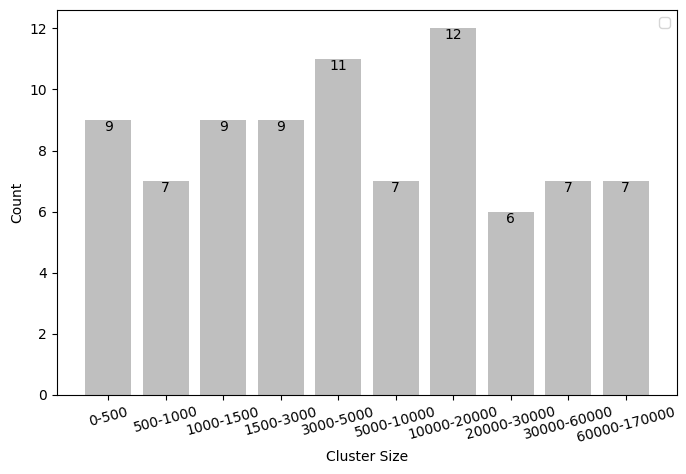

In [113]:
import matplotlib.pyplot as plt
from collections import Counter

#segments = [(1, 2), (2, 10),(10, 100),(100, 500),(500, 1000),(1000, 2000)]
segments = [(0, 500), (500, 1000),(1000, 1500),(1500, 3000),(3000, 5000),(5000, 10000),(10000, 20000),(20000, 30000),(30000, 60000),(60000, 170000)]


def cluster_size_count(your_list):

    counter = Counter(your_list)
    #segments = [(50, 100),(100, 200),(200, 350),(350, 500),(500, 700),(700, 900)]

    segment_counts = {segment: 0 for segment in segments}

    for element, count in counter.items():
        for segment in segments:
            if segment[0] <= element < segment[1]:
                segment_counts[segment] += count
    return segment_counts
# 将统计结果转换为两个列表，分别包含段和对应的计数
_,  counts_fold = zip(*cluster_size_count(augu_dic_len).items())
#_,  counts_fli = zip(*cluster_size_count(Allfold_universe_len_false).items())

# 画柱状图
plt.figure(figsize=(8, 5))
bars_fold = plt.bar(range(len(segments)), counts_fold,color='gray', alpha=0.5, tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])
#bars_fli = plt.bar(range(len(segments)), counts_fli,color='salmon', alpha=0.5,label='EC not consistent' , tick_label=[f"{segment[0]}-{segment[1]}" for segment in segments])

plt.xlabel('Cluster Size')
plt.ylabel('Count')
#plt.title('Segmented Counts')
plt.grid(False)
for bar in bars_fold:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='top')
#for bar in bars_fli:
#    yval = bar.get_height()
#    plt.text(bar.get_x() + bar.get_width() / 2, yval, round(yval, 2), ha='center', va='bottom')
plt.legend()
plt.xticks(rotation=15)
plt.show()

In [167]:
for key in set(keys_uni_augu):
    get_fasta_universe(key)

In [169]:
EC_anno = {}
for i in range(len(items_uni_augu)):
    
    EC_anno[items_uni_augu[i]]= ';'.join(id_ec[Universe2Local_data[keys_uni_augu[i]]])
    

In [ ]:
Allfold_universe_data
Allfold_universe_len_key
Allfold_universe_len_true_key
Allfold_universe_len_false_key



In [209]:
hf1 =  h5py.File(proVec_embfile , 'r')
list(hf1.keys())[0]

'A0A009EDD3'

In [132]:
hf1 =  h5py.File(proVec_embfile , 'r')
hf2 =  h5py.File(proVec_embfile2, 'r')
proteins_embed_dic = {}
for key in list(hf1.keys()):
    proteins_embed_dic[key] = hf1[key][:]
for key in list(hf2.keys()):
    proteins_embed_dic[key] = hf2[key][:]

In [133]:
len(proteins_embed_dic)

551200

In [318]:
import h5py
proVec_embfile = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/proteins_embed_dic1_1000_2000'
proVec_embfile2 = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/proteins_embed_dic2_1000_2000'


 
def load_proVec(lookup):
    
    if lookup in list(hf1.keys()):
        with h5py.File(proVec_embfile , 'r') as hf:
                dataset_name = lookup
                dataset = hf[dataset_name]
                data = dataset[:]
                #data = torch.tensor(data).unsqueeze(0)
    
    elif lookup in list(hf2.keys()):
        with h5py.File(proVec_embfile2 , 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]
            data = dataset[:]
            #data = torch.tensor(data).unsqueeze(0)
    else:
        data = 'False'
    
    return data #torch.tensor(data).unsqueeze(0)


def load_proVecc(lookup):
    
    hf1 =  h5py.File(proVec_embfile , 'r')
    hf2 =  h5py.File(proVec_embfile2, 'r')
    if lookup in list(hf1.keys()):
        dataset_name = lookup
        dataset = hf1[dataset_name]
        data = dataset[:][0]
        data = torch.tensor(data).unsqueeze(0)
    elif lookup in list(hf2.keys()):
        dataset_name = lookup
        dataset = hf2[dataset_name]
        data = dataset[:][0]
        data = torch.tensor(data).unsqueeze(0)
    else:
        data = 'False'
    
    
    hf1.close()
    hf2.close()
    #torch_data = torch.tensor(data)
    return data #torch.tensor(data).unsqueeze(0)


def cos_sim(vector1,vector2):
    # Compute dot product
    dot_product = np.dot(vector1, vector2)

    # Compute magnitudes
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)

    # Compute cosine similarity
    similarity = dot_product / (magnitude1 * magnitude2)
    return similarity


from sklearn.metrics.pairwise import cosine_similarity

def Universe_foldseek_clusterProvec(key):
    clusterProvec = []
    for item in Allfold_universe_data[key]:
        data = load_proVec(item)
        if data != 'False':
            clusterProvec.append(data)
    return clusterProvec

def foldseek_clusterProvec(key):
    clusterProvec = []
    for item in fun_fold[key]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def repfoldseek_clusterProvec(key):
    clusterProvec = []
    for item in rep_fold[key]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def EC_clusterProvec(EC):
    clusterProvec = []
    for item in ec_id[EC]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def cluster_cos_sim(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)
    # 去掉对角线的值
    np.fill_diagonal(similarities, 0)
    mask = np.triu(np.ones(similarities.shape), k=1).astype(bool)
    similarities_half = similarities[mask]
    return similarities_half

def cluster_cos_sim_full(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)
    
    return similarities


In [145]:
cluster_cos_sim_full(UniverseFASTA_foldseek_clusterProvec(Allfold_universe_len_key[0]))

array([[1.0000001, 1.0000001, 1.       , ..., 1.0000002, 1.0000002,
        1.       ],
       [1.0000001, 1.0000001, 1.       , ..., 1.0000002, 1.0000002,
        1.       ],
       [1.       , 1.       , 1.0000001, ..., 1.0000002, 1.0000002,
        1.0000001],
       ...,
       [1.0000002, 1.0000002, 1.0000002, ..., 1.0000001, 1.0000001,
        1.0000001],
       [1.0000002, 1.0000002, 1.0000002, ..., 1.0000001, 1.0000001,
        1.0000001],
       [1.       , 1.       , 1.0000001, ..., 1.0000001, 1.0000001,
        1.0000001]], dtype=float32)

In [365]:
def cluster_cos_sim_full(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)
    
    return similarities

def UniverseSample_foldseek_clusterProvec(key):
    
    clusterProvec = []
    for item in proteins_embed_dic.keys():
        
            data = proteins_embed_dic[item]
            if data is not False:
                clusterProvec.append(data)
    return clusterProvec

file = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/proteins_embed_dic_P20921_Mix'
hf =  h5py.File(file, 'r')
proteins_embed_dic = {}
for key in list(hf.keys()):
    proteins_embed_dic[key] = hf[key][:]

case_Fun = cluster_cos_sim_full(UniverseSample_foldseek_clusterProvec('P20921'))

In [367]:
case_Fun = cluster_cos_sim_full(UniverseSample_foldseek_clusterProvec('P20921'))

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



# 计算余弦相似度
similarities = case_Fun


# 使用seaborn绘制热图
sns.heatmap(similarities, cmap="YlGnBu", vmin=0.99988, vmax=1)
#plt.title("Cosine Similarity Heatmap")
plt.xlabel("Sample of Q7N2V3 cluster")
plt.ylabel("Sample of Q7N2V3 cluster")
plt.xticks([])
plt.yticks([])
plt.show()

In [319]:
fun_simfold_Prosim = {}
for key in keys_nosingle_universe:
    cluster = UniverseFASTA_foldseek_clusterProvec(key)
    print(key)
    if len(cluster)>1:
        fun_simfold_Prosim[key] = cluster_cos_sim_full(cluster)


A0A010R299
A0A067MSI7
A0A075AY95
A0A081NGI5
A0A090M7H2
A0A090SA30
A0A095B091
A0A098SCN4
A0A0A3AI72
A0A0A9WTQ0
A0A0A9YG42
A0A0B2AML7
A0A0B7F540
A0A0B7FF65
A0A0D1EKR2
A0A0D2JCL2
A0A0D3GMR1
A0A0D7B6I6
A0A0G0CZ30
A0A0K2SGA7
A0A0K9NR35
A0A0L0H9S4
A0A0M7FQJ9
A0A0N1FUC6
A0A0P1NV83
A0A0P6X0Q2
A0A0Q0VUI2
A0A0Q7IAE1
A0A0Q7NGA7
A0A0R2I1X9
A0A0R3RWG0
A0A0V1FBY4
A0A100JPX5
A0A182N068
A0A194YNK8
A0A196SIK3
A0A1B2I777
A0A1B5CTN8
A0A1B7LL87
A0A1C3NVH7
A0A1C6JDV5
A0A1C7PI52
A0A1E3QV16
A0A1E5UPW0
A0A1F3Q3P1
A0A1F4U670
A0A1F7SMX9
A0A1G2I336
A0A1I6RI55
A0A1J7GDM6
A0A1L9RC63
A0A1L9SHW8
A0A1R4EFW9
A0A1S1HM35
A0A1S2YV81
A0A1S3K599
A0A1S3M1Z1
A0A1S8LE60
A0A1S8W9B6
A0A1S9AMK8
A0A1V5KKB6
A0A1V6A8L0
A0A1V6GWV2
A0A1V8V654
A0A1X7SXS4
A0A1Y1HND0
A0A1Y1ZBR6
A0A1Y6BLP2
A0A1Z8UEL7
A0A200RA88
A0A211YS46
A0A212PHG8
A0A222EZI2
A0A239INT7
A0A251X1V8
A0A256Z792
A0A257LQF6
A0A261Y7I2
A0A263DHB0
A0A286UMB1
A0A287HR86
A0A2A4FS88
A0A2D0H964
A0A2D4M597
A0A2D6P4Z8
A0A2D6QNP8
A0A2E2WMJ4
A0A2E3NH29
A0A2E8XIW9
A0A2G1ZZ11
A0A2G6KGU0

In [224]:
universe_clu = {}
for key in Allfold_universe_len_key:
    file_path = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Universe_1000_2000/'+ key+ '.fasta'
    sequences_dict = fasta_to_dict(file_path)
    universe_clu[key] = list(sequences_dict.keys())

In [225]:
len(universe_clu)

438

In [337]:
def UniverseFASTA_foldseek_clusterProvec(key):
    
    clusterProvec = []
    for item in universe_clu[key]:
        if item in proteins_embed_dic.keys():
            data = proteins_embed_dic[item]
            if data is not False:
                clusterProvec.append(data)
    return clusterProvec

In [103]:
Uni_list = os.listdir('/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Universe_1000_2000')

In [104]:
items = []
for key in Allfold_universe_len_key:
    keys = key + '.fasta'
    if keys not in Uni_list:
        items.append(key)

In [105]:
len(items)

0

In [106]:
len(Allfold_universe_len_key)

438

In [320]:
all_sim_W_Av = []
True_funClu_W_Av = []
False_funClu_W_Av = []

for key in fun_simfold_Prosim.keys():

    all_sim_W_Av.append(np.mean(fun_simfold_Prosim[key]))
    if key in Allfold_universe_len_true_key:
        True_funClu_W_Av.append(np.mean(fun_simfold_Prosim[key]))
    else:
        False_funClu_W_Av.append(np.mean(fun_simfold_Prosim[key]))


In [321]:
all_sim_W_var = []
True_funClu_W_var = []
False_funClu_W_var = []

for key in fun_simfold_Prosim.keys():
    
    all_sim_W_var.append(np.var(fun_simfold_Prosim[key]))
    if key in Allfold_universe_len_true_key:
        True_funClu_W_var.append(np.var(fun_simfold_Prosim[key]))
    else:
        False_funClu_W_var.append(np.var(fun_simfold_Prosim[key]))

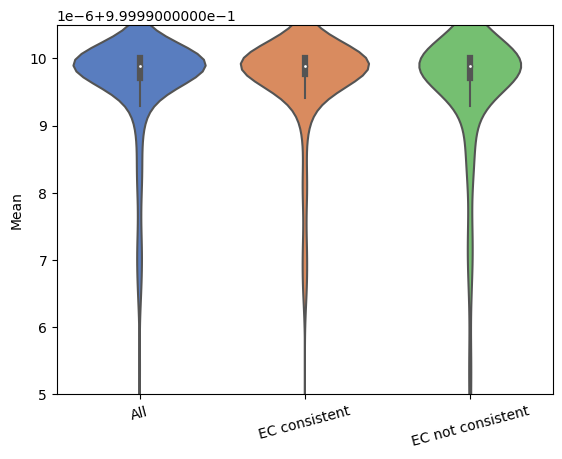

In [324]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = all_sim_W_Av
data2 = True_funClu_W_Av
data3 = False_funClu_W_Av
# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2,data3], palette="muted", orient='v')

#plt.title('Vertical Violin Plot - Data Distribution')
#plt.xlabel('Density')
plt.ylabel('Mean')
#plt.ylabel('Various')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['All', 'EC consistent','EC not consistent'])
plt.xticks(rotation=15)
plt.ylim(0.999995, 1.0000005) 
#plt.ylim(0.9995, 1.000005) 
#plt.ylim(0, 0.00000002) 
plt.show()

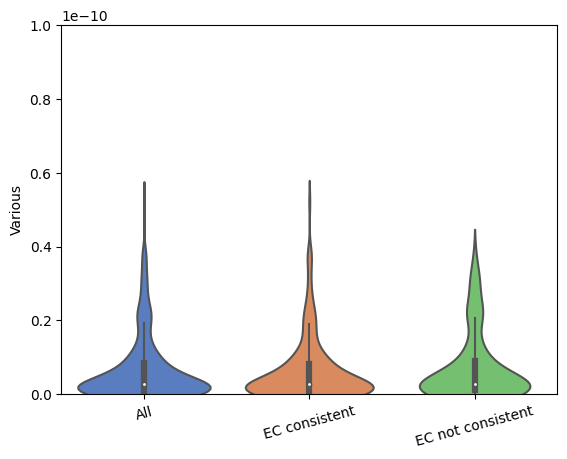

In [325]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = all_sim_W_var
data2 = True_funClu_W_var
data3 = False_funClu_W_var
# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2,data3], palette="muted", orient='v')

#plt.title('Vertical Violin Plot - Data Distribution')
#plt.xlabel('Density')
plt.ylabel('Various')
#plt.ylabel('Various')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['All', 'EC consistent','EC not consistent'])
plt.xticks(rotation=15)
#plt.ylim(0, 0.00000002) 
plt.ylim(0, 0.0000000001) 
plt.show()

In [280]:
Allfold_local_len_key= []
keys_nosingle_local = []
keys_nosingle_universe = []
for key in Allfold_universe_len_key:
    Allfold_local_len_key.append(Universe2Local_data[key])
    if len(fun_fold[Universe2Local_data[key]])!= 1:
        keys_nosingle_local.append(Universe2Local_data[key])
        keys_nosingle_universe.append(key)

In [286]:
len(set(keys_nosingle_local))

351

In [327]:
Mems_local = []
for key in keys_nosingle_local:
    Mems_local.extend(fun_fold[key])
Mems_universe = []
for key in keys_nosingle_universe:
    Mems_universe.extend(Allfold_universe_data[key])

In [328]:
len(Mems_local)

11792

In [329]:
len(Mems_universe)

506261

In [282]:
clu_size_local = []

for key in keys_nosingle_local:
    
    clu_size_local.append(len(fun_fold[key]))
    
clu_size_universe = []
for key in keys_nosingle_universe:
    clu_size_universe.append(len(Allfold_universe_data[key]))

In [283]:
print(np.mean(clu_size_local),min(clu_size_local),max(clu_size_local))

33.59544159544159 2 1218


In [284]:
print(np.mean(clu_size_universe),min(clu_size_universe),max(clu_size_universe))

1442.3390313390314 1001 1999


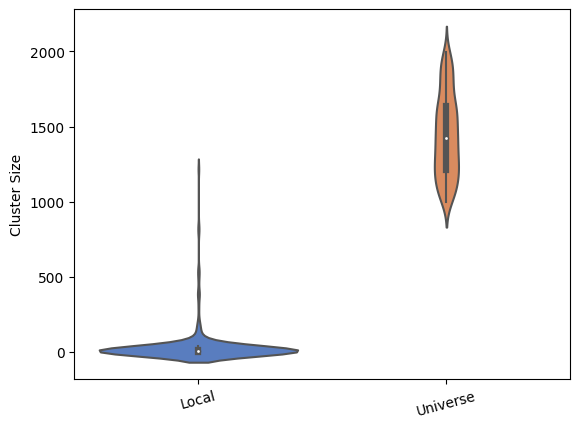

In [285]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = clu_size_local
data2 = clu_size_universe

# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2], palette="muted", orient='v')

#plt.title('Vertical Violin Plot - Data Distribution')
#plt.xlabel('Density')
plt.ylabel('Cluster Size')
#plt.ylabel('Various')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1])
ax.set_xticklabels(['Local', 'Universe'])
plt.xticks(rotation=15)
#plt.ylim(0, 10) 
#plt.ylim(0, 0.00000002) 
plt.show()

In [287]:
import h5py
proVec_embfile = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Enzyme_proteins_embed_dic'
miss_embvalue = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Miss_proteins_embed_dic'
miss_data = ['P20894', 'A0A0U1LSP0', 'Q03498', 'Q8MU52', 'A0A140CUL9', 'W6JQJ6','B3IVI7', 'Q88QV2']
def load_proVec(lookup):
    if lookup not in miss_data:
        with h5py.File(proVec_embfile , 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]


            data = dataset[:][0]
    else:
        with h5py.File(miss_embvalue , 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]


            data = dataset[:][0]

    #torch_data = torch.tensor(data)
    return data #torch_data.unsqueeze(0)


def cos_sim(vector1,vector2):
    # Compute dot product
    dot_product = np.dot(vector1, vector2)

    # Compute magnitudes
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)

    # Compute cosine similarity
    similarity = dot_product / (magnitude1 * magnitude2)
    return similarity


from sklearn.metrics.pairwise import cosine_similarity

def foldseek_clusterProvec(key):
    clusterProvec = []
    for item in fun_fold[key]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def repfoldseek_clusterProvec(key):
    clusterProvec = []
    for item in rep_fold[key]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def EC_clusterProvec(EC):
    clusterProvec = []
    for item in ec_id[EC]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def cluster_cos_sim(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)
    # 去掉对角线的值
    np.fill_diagonal(similarities, 0)
    mask = np.triu(np.ones(similarities.shape), k=1).astype(bool)
    similarities_half = similarities[mask]
    return similarities_half

def cluster_cos_sim_full(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)
    
    return similarities


In [297]:
import h5py
proVec_embfile = '/Users/eth-may/Desktop/dtu/semester7/Thesis/data/Embedding/proteins_embed_dic_MF'
def load_proVec(lookup):
    
    with h5py.File(proVec_embfile , 'r') as hf:
            dataset_name = lookup
            dataset = hf[dataset_name]


            data = dataset[:][0]

    #torch_data = torch.tensor(data)
    return data #torch_data.unsqueeze(0)


def cos_sim(vector1,vector2):
    # Compute dot product
    dot_product = np.dot(vector1, vector2)

    # Compute magnitudes
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)

    # Compute cosine similarity
    similarity = dot_product / (magnitude1 * magnitude2)
    return similarity


from sklearn.metrics.pairwise import cosine_similarity

def foldseek_clusterProvec(key):
    clusterProvec = []
    for item in fun_fold[key]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def repfoldseek_clusterProvec(key):
    clusterProvec = []
    for item in rep_fold[key]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def EC_clusterProvec(EC):
    clusterProvec = []
    for item in ec_id[EC]:
        clusterProvec.append(load_proVec(item))
    return clusterProvec

def cluster_cos_sim(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)
    # 去掉对角线的值
    np.fill_diagonal(similarities, 0)
    mask = np.triu(np.ones(similarities.shape), k=1).astype(bool)
    similarities_half = similarities[mask]
    return similarities_half

def cluster_cos_sim_full(cluster):

    # Reshape the cluster if needed
    cluster = np.array(cluster).reshape(len(cluster), -1)

    # Compute pairwise cosine similarities
    similarities = cosine_similarity(cluster)
    
    return similarities


In [298]:
fun_simfold_Prosim = {}
for key in keys_nosingle_local:
    fun_simfold_Prosim[key] = cluster_cos_sim_full(foldseek_clusterProvec(key))

In [299]:
all_sim_W_Av = []
True_funClu_W_Av = []
False_funClu_W_Av = []

for key in fun_simfold_Prosim.keys():

    all_sim_W_Av.append(np.mean(fun_simfold_Prosim[key]))
    if key in uni_fun_fold_keys:
        True_funClu_W_Av.append(np.mean(fun_simfold_Prosim[key]))
    else:
        False_funClu_W_Av.append(np.mean(fun_simfold_Prosim[key]))

all_sim_W_var = []
True_funClu_W_var = []
False_funClu_W_var = []

for key in fun_simfold_Prosim.keys():
    
    all_sim_W_var.append(np.var(fun_simfold_Prosim[key]))
    if key in uni_fun_fold_keys:
        True_funClu_W_var.append(np.var(fun_simfold_Prosim[key]))
    else:
        False_funClu_W_var.append(np.var(fun_simfold_Prosim[key]))

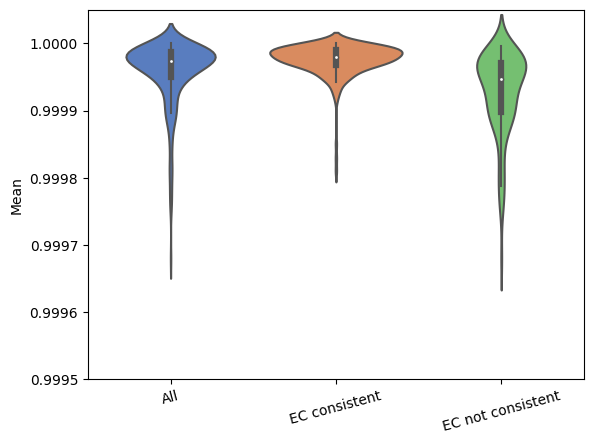

In [300]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = all_sim_W_Av
data2 = True_funClu_W_Av
data3 = False_funClu_W_Av
# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2,data3], palette="muted", orient='v')

#plt.title('Vertical Violin Plot - Data Distribution')
#plt.xlabel('Density')
plt.ylabel('Mean')
#plt.ylabel('Various')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['All', 'EC consistent','EC not consistent'])
plt.xticks(rotation=15)
plt.ylim(0.9995, 1.00005) 
#plt.ylim(0, 0.00000002) 
plt.show()

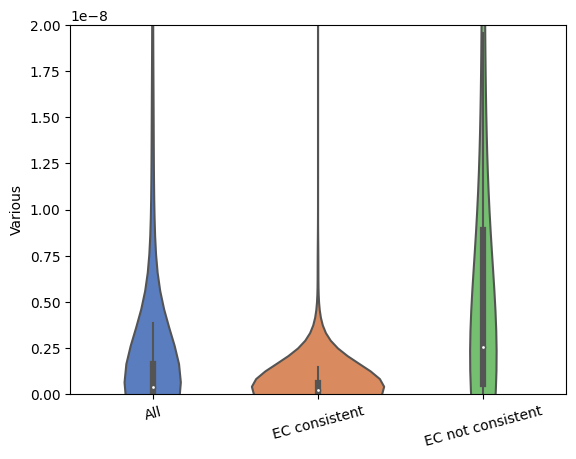

In [301]:
import seaborn as sns
import matplotlib.pyplot as plt

# 两个数据列表
data1 = all_sim_W_var
data2 = True_funClu_W_var
data3 = False_funClu_W_var
# 使用 Seaborn 绘制两个响铃图在同一个图上
ax = sns.violinplot(data=[data1, data2,data3], palette="muted", orient='v')

#plt.title('Vertical Violin Plot - Data Distribution')
#plt.xlabel('Density')
plt.ylabel('Various')
#plt.ylabel('Various')
plt.grid(False)
# 设置 x 轴的刻度和标签
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['All', 'EC consistent','EC not consistent'])
plt.xticks(rotation=15)
#plt.ylim(0.9995, 1.00005) 
plt.ylim(0, 0.00000002) 
plt.show()